# Lab 10 — Drift & Performance Experiment
### *Detect distribution shift, then test whether performance actually changed.*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/labs/drift_lab.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---

## Overview
In Week 9 you learned metrics. In Week 10 we operationalize them:

You will:
1) define a **baseline** dataset and a **drifted** dataset,
2) compute drift indicators (no labels needed),
3) compute a performance metric (labels needed),
4) write a short “ops report”: detect → triage → mitigate.

---

## Learning goals
- Compute simple drift metrics: length drift + embedding centroid drift.
- Implement one histogram drift metric (PSI-style) on a chosen feature.
- Build a tiny embedding retriever and compute **recall@k**.
- Compare baseline vs drifted performance and propose an ops action.
- Practice the scientific loop: change X → observe Y → compare to hypothesis.


In [ ]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("/content/main")
from course_utils import get_text_embedding, lab10_setup

lab10_setup()
print("✅ Environment ready!")


installing mermaid-python
Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
installing dspy
✅ Environment ready!


## Pre-Lab Questions
Answer in 1–2 sentences each. (Edit this cell.)

1. What’s one reason a model system can get worse even if your code doesn’t change?
2. Name one thing you should *not* log in production.
3. If recall@k drops, what are two possible causes?

Your answers:
1)  
2)  
3)


## Scientific Question & Hypothesis

**Question:**  
If we change **X = input distribution** (baseline vs drifted), what happens to **Y =** drift metrics *and* retrieval performance (recall@k)?

**My hypothesis:**  
I expect drift metrics will _________, and recall@k will _________, because _________.

Write your hypothesis here:


## Scientific process plan
- **Question:** Does drift predict performance degradation?
- **Hypothesis:** written above
- **Experiment:** run baseline vs drifted dataset through the same retriever
- **Measurement:** drift metrics (length, PSI-style, embedding centroid shift) + recall@k
- **Conclusion:** propose an ops action (mitigation) and how you'd validate it


# Part 1 — Build a tiny retrieval setup (provided)
We’ll use a small “policy-like” corpus and an embedding retriever.
This is intentionally small so you can understand it.


In [ ]:
# @title Tiny corpus (provided)
corpus = [
    {"doc_id":"policy_oncall", "text":"Interns may join on-call only after onboarding and manager approval. Start with shadow shifts."},
    {"doc_id":"policy_access", "text":"Interns may NOT access customer production data. Elevated access requires manager approval."},
    {"doc_id":"runbook_incidents", "text":"Responders should acknowledge the page, assess severity, mitigate, communicate updates, and write a postmortem."},
    {"doc_id":"faq_security", "text":"Security training is required for elevated access. Use least privilege and log access reviews."},
]

def normalize(v):
    v = np.asarray(v, dtype=np.float32)
    return v / (np.linalg.norm(v) + 1e-12)

def embed(text):
    return normalize(get_text_embedding(text))

X_docs = np.vstack([embed(d["text"]) for d in corpus])
doc_ids = [d["doc_id"] for d in corpus]

def topk_docs(query, k=3):
    q = embed(query)
    sims = X_docs @ q
    idx = np.argsort(-sims)[:k]
    return [doc_ids[int(i)] for i in idx]

topk_docs("Can interns join on-call?", k=3)


['policy_oncall', 'policy_access', 'faq_security']

# Part 2 — Baseline vs drifted datasets (provided, but editable)
These datasets include a gold doc id (the correct retrieval target).

You can edit questions to create different types of drift:
- longer questions (copy/paste behavior)
- new wording / synonyms (“prod” vs “production”)
- more “attack-like” language


In [ ]:
# @title Baseline + drifted eval sets (provided)
baseline = [
    {"q":"Can interns join the on-call rotation?", "gold":{"policy_oncall"}},
    {"q":"Do interns get production access?", "gold":{"policy_access"}},
    {"q":"What do incident responders do during an incident?", "gold":{"runbook_incidents"}},
    {"q":"What is required for elevated access?", "gold":{"faq_security", "policy_access"}},
]

drifted = [
    {"q":"We changed staffing recently — are interns allowed to do oncall shifts yet, or do they need approval?", "gold":{"policy_oncall"}},
    {"q":"Do interns get prod access to customer data after onboarding? Please be specific.", "gold":{"policy_access"}},
    {"q":"During an outage, what are responders supposed to do? Include all steps and context.", "gold":{"runbook_incidents"}},
    {"q":"What's needed for elevated privileges / elevated access? I'm in a rush.", "gold":{"faq_security", "policy_access"}},
]
len(baseline), len(drifted)


(4, 4)

# Part 3 — Drift metrics (TODOs)
You will implement three drift indicators:

1) **Length drift** (easy)
2) **Embedding centroid shift**
3) **PSI-style histogram drift** for one feature (you choose)

PSI-style intuition:
- bucket a feature into bins
- compare baseline vs current frequencies
- large changes → drift


In [ ]:
# @title ✅ TODO: Implement drift metrics
def length_stats(questions):
    # TODO: return dict with mean_len and p90_len (90th percentile)
    raise NotImplementedError("Implement length_stats")

def embedding_centroid_shift(questions_a, questions_b):
    # TODO: return cosine distance between mean embeddings
    raise NotImplementedError("Implement embedding_centroid_shift")

def psi_histogram(feature_a, feature_b, bins):
    '''
    PSI-style drift using discrete bins.

    Steps:
    1) bucket features into bins
    2) compute frequencies pa and pb (add tiny epsilon to avoid /0)
    3) compute sum( (pb - pa) * ln(pb/pa) )

    Return a single float (bigger means more drift).
    '''
    raise NotImplementedError("Implement psi_histogram")


In [ ]:
# @title Compute drift metrics (scaffold)
qA = [x["q"] for x in baseline]
qB = [x["q"] for x in drifted]

# Feature for PSI: length in chars (you could also use word count)
featA = [len(q) for q in qA]
featB = [len(q) for q in qB]
bins = [0, 50, 100, 150, 250, 500, 1000]

lsA = length_stats(qA)
lsB = length_stats(qB)
cent = embedding_centroid_shift(qA, qB)
psi = psi_histogram(featA, featB, bins=bins)

print("Length stats baseline:", lsA)
print("Length stats drifted :", lsB)
print("Embedding centroid shift:", round(cent, 3))
print("PSI-style length drift :", round(psi, 3))


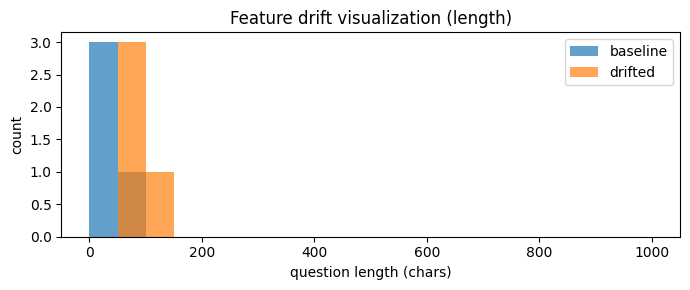

In [ ]:
# @title Plot: baseline vs drifted feature distributions (provided)
plt.figure(figsize=(7,3))
plt.hist(featA, bins=bins, alpha=0.7, label="baseline")
plt.hist(featB, bins=bins, alpha=0.7, label="drifted")
plt.xlabel("question length (chars)")
plt.ylabel("count")
plt.title("Feature drift visualization (length)")
plt.legend()
plt.tight_layout()
plt.show()


### Reflection
- Which drift metric changed the most?
- Do the drift metrics agree (all say “more drift”), or do they disagree?

Write here:


# Part 4 — Performance metric: retrieval recall@k
We’ll compute **recall@k**:
- for each question, retrieve top‑k docs
- success if any gold doc appears in top‑k
- recall@k = fraction of questions that succeed

This is exactly the kind of canary evaluation you might run daily in production.


In [ ]:
# @title ✅ TODO: Implement recall@k
def recall_at_k(eval_set, k=3):
    # TODO: retrieve topk_docs(item["q"], k), check gold intersects
    raise NotImplementedError("Implement recall_at_k")


In [ ]:
# @title Run recall@k for baseline vs drifted (scaffold)
for k in [1, 2, 3]:
    rA = recall_at_k(baseline, k=k)
    rB = recall_at_k(drifted, k=k)
    print(f"Recall@{k}: baseline={rA:.2f}  drifted={rB:.2f}")


## Part 5 — Write a short “ops report” (student writing)
Pretend you’re on call for this system.

Write 6–10 sentences:
- What did you detect? (which metrics changed)
- What is your best hypothesis for why?
- What is your mitigation? (e.g., update docs, add synonyms, change prompts, add reranker)
- How would you validate the fix before deploying?

Write your ops report here:


## Results
Summarize:
- drift metric values (baseline vs drifted)
- recall@k comparison
- whether drift predicted performance change

Write here:


## Conclusion
- Was your hypothesis supported?
- What did you learn about monitoring and drift?
- What would you log next time to make debugging easier?

Write here:


## Post-Lab Reflection
Answer briefly (2–4 sentences each). (Edit this cell.)

1. Which drift metric felt most useful, and why?
2. What is one way drift metrics could be misleading?
3. If you could add one new monitor to your deployed app, what would it be?

Your answers:
1)  
2)  
3)


---

## 🧠 AI Usage Log

> Use this section to document any generative AI assistance (e.g., ChatGPT, Claude, Copilot) you used while completing this lab or assignment.  
> Be specific — transparency and reflection matter more than the amount of AI use.


| Tool Used | Purpose | Prompt / Context | Verification & Edits |
|------------|----------|------------------|----------------------|
| (e.g., ChatGPT (GPT-5)) | (e.g., debugging, code explanation, idea generation) | (e.g., "Why does my cosine similarity return NaN?") | (e.g., ran tests on sample input, compared with lecture code) |
| (Add rows as needed) | | | |

**Summary (2–3 sentences):**  
Briefly describe what you learned or how AI helped you think through the problem.  
Example: *AI helped me notice an off-by-one error in my indexing. I double-checked by printing intermediate results and confirmed the fix.*

---



In [ ]:
# @title ✅ Checks for Lab 10
print("Running checks...")

try:
    d = length_stats(["a", "abcd"])
    assert "mean_len" in d and "p90_len" in d
    print("✅ length_stats ok")
except Exception as e:
    print("❌ length_stats failed:", e)

try:
    s = embedding_centroid_shift(["hello"], ["hello world"])
    assert isinstance(s, float)
    print("✅ embedding_centroid_shift ok")
except Exception as e:
    print("❌ embedding_centroid_shift failed:", e)

try:
    v = psi_histogram([1,2,3],[2,3,4], bins=[0,2,4,6])
    assert isinstance(v, float)
    print("✅ psi_histogram ok")
except Exception as e:
    print("❌ psi_histogram failed:", e)

try:
    r = recall_at_k(baseline, k=2)
    assert 0 <= r <= 1
    print("✅ recall_at_k ok")
except Exception as e:
    print("❌ recall_at_k failed:", e)

print("Done.")
